## SOFTMAX on MNIST

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [6]:
# loading MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int32)

X /= 255.0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# one-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.values.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.values.reshape(-1, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (56000, 784)
Test data shape: (14000, 784)


In [7]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True)) 
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    n_samples = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(n_samples), y_true.argmax(axis=1)])
    loss = np.sum(log_likelihood) / n_samples
    return loss

def softmax_gradient(y_pred, y_true):
    return y_pred - y_true

In [8]:
input_size = 784  # 28x28 pixels
output_size = 10  
lr = 0.01
epochs = 300

W = np.random.randn(input_size, output_size) * 0.01
b = np.zeros((1, output_size))

In [9]:
# training loop
for epoch in range(epochs):
    # forward pass
    z = np.dot(X_train, W) + b
    y_pred = softmax(z)
    
    loss = cross_entropy_loss(y_pred, y_train_onehot)
    
    # backward pass
    dz = softmax_gradient(y_pred, y_train_onehot)
    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]
    
    # update parameters
    W -= lr * dW
    b -= lr * db
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

Epoch 10/300, Loss: 2.2058
Epoch 20/300, Loss: 2.1098
Epoch 30/300, Loss: 2.0210
Epoch 40/300, Loss: 1.9386
Epoch 50/300, Loss: 1.8621
Epoch 60/300, Loss: 1.7912
Epoch 70/300, Loss: 1.7255
Epoch 80/300, Loss: 1.6645
Epoch 90/300, Loss: 1.6079
Epoch 100/300, Loss: 1.5554
Epoch 110/300, Loss: 1.5066
Epoch 120/300, Loss: 1.4613
Epoch 130/300, Loss: 1.4191
Epoch 140/300, Loss: 1.3798
Epoch 150/300, Loss: 1.3432
Epoch 160/300, Loss: 1.3090
Epoch 170/300, Loss: 1.2770
Epoch 180/300, Loss: 1.2470
Epoch 190/300, Loss: 1.2189
Epoch 200/300, Loss: 1.1925
Epoch 210/300, Loss: 1.1676
Epoch 220/300, Loss: 1.1442
Epoch 230/300, Loss: 1.1222
Epoch 240/300, Loss: 1.1013
Epoch 250/300, Loss: 1.0816
Epoch 260/300, Loss: 1.0629
Epoch 270/300, Loss: 1.0452
Epoch 280/300, Loss: 1.0284
Epoch 290/300, Loss: 1.0124
Epoch 300/300, Loss: 0.9972


Test Accuracy: 82.29%


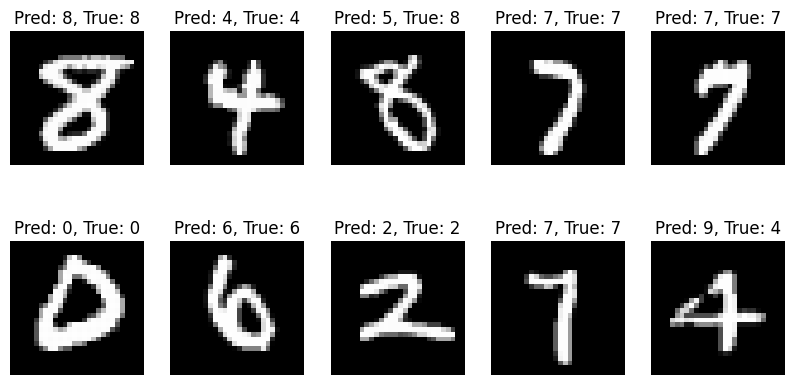

In [10]:
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
predictions = np.argmax(y_pred_test, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

accuracy = np.mean(predictions == true_labels)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# visualization
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test.iloc[i].values.reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {predictions[i]}, True: {true_labels[i]}")
    ax.axis('off')
plt.show()

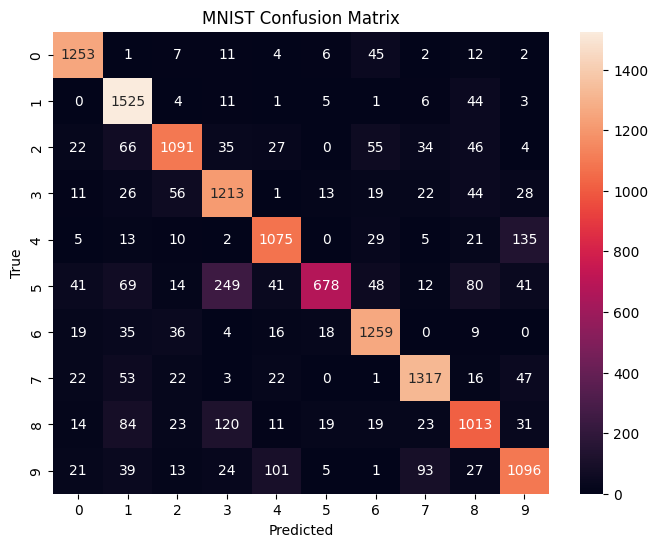

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()

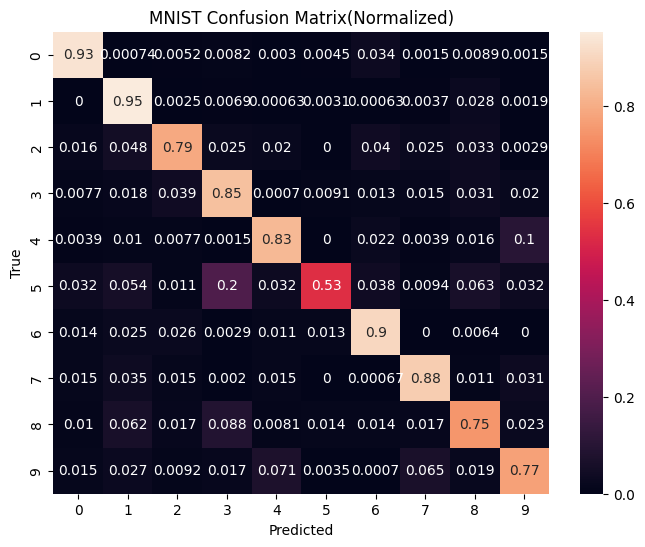

In [12]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix(Normalized)")
plt.show()

In [13]:
def tolerant_accuracy(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) <= 1)

print("Tolerant accuracy:", tolerant_accuracy(y_test, predictions))

Tolerant accuracy: 0.8492857142857143


Number of misclassified samples: 2480


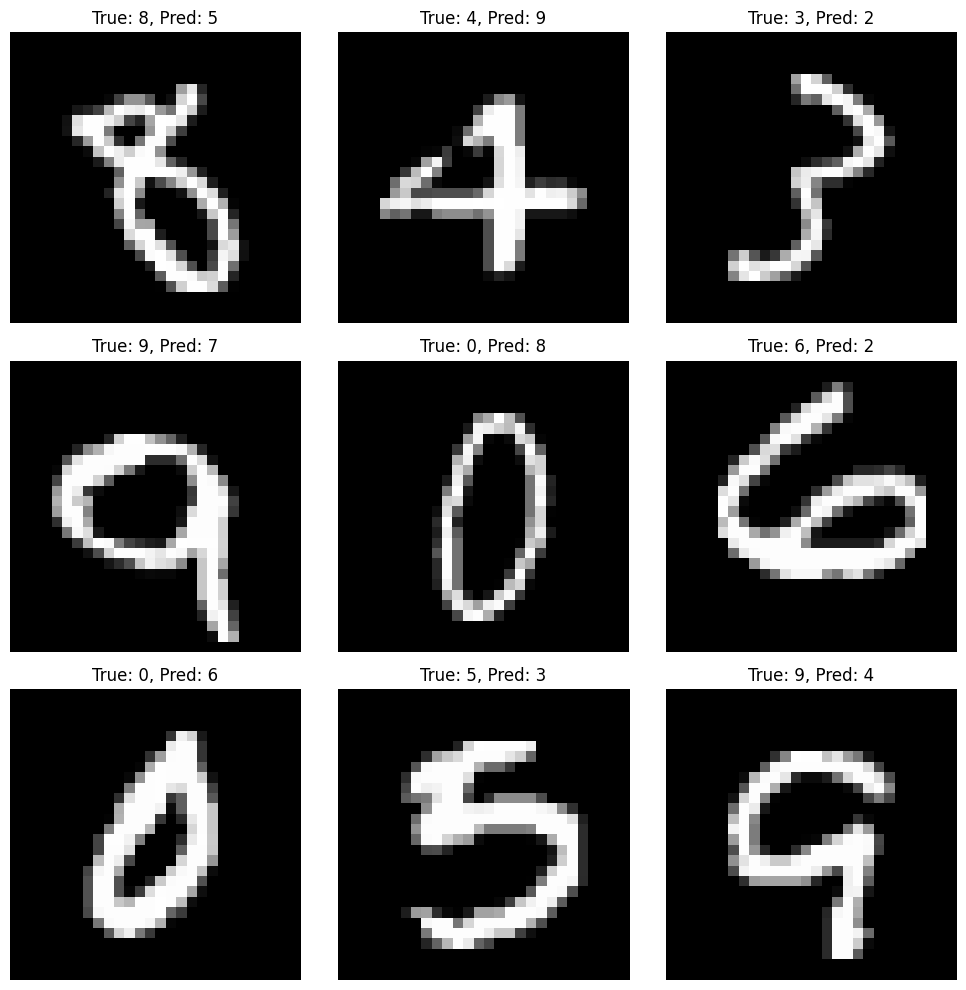

In [60]:
misclassified = np.where(predictions != y_test)[0]
print(f"Number of misclassified samples: {len(misclassified)}")

plt.figure(figsize=(10,10))

for i in range(9):
    idx = misclassified[i]
    
    image = X_test.iloc[idx].values.reshape(28, 28)

    plt.subplot(3, 3, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_test.iloc[idx]}, Pred: {predictions[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()



---
## SoftRec on MNIST

- **Base**: one-hot + CE
- **LS**: label smoothing (uniform)
- **POP+**: class-prior soft targets + adjustment
- **CSN**: neighborhood soft targets (in-batch nearest neighbor) + stop-grad teacher snapshot
- **SKD**: self knowledge distillation (EMA teacher)
- **CKD**: cross-architecture KD (teacher = MLP)

In [ ]:
def softmax_T(z, T=1.0):
    zT = z / T
    zT = zT - np.max(zT, axis=1, keepdims=True)
    exp_z = np.exp(zT)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot_np(y, num_classes=10):
    oh = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    oh[np.arange(y.shape[0]), y] = 1.0
    return oh

def cross_entropy_soft(y_pred, y_soft):
    eps = 1e-12
    return -np.mean(np.sum(y_soft * np.log(y_pred + eps), axis=1))

def fuse_targets(q, d, alpha):
    return (1.0 - alpha) * q + alpha * d

def label_smoothing_targets(y, eps=0.1, num_classes=10):
    q = one_hot_np(y, num_classes)
    u = np.full_like(q, 1.0/num_classes)
    return (1-eps)*q + eps*u

def class_prior(y_train, num_classes=10):
    counts = np.bincount(y_train, minlength=num_classes).astype(np.float64)
    prior = counts / counts.sum()
    return prior.astype(np.float32)

def pop_plus_targets(y, prior, T=1.0, num_classes=10):
    q = one_hot_np(y, num_classes)
    logits = (np.log(prior + 1e-12) / T).reshape(1,-1)
    pop = softmax_T(logits, T=1.0)  
    pop = pop.reshape(-1) 
    d = 0.5 * (pop[None,:] + q)
    return d

def kd_adjusted_targets(y, p_teacher, num_classes=10):
    q = one_hot_np(y, num_classes)
    d = 0.5 * (p_teacher + q)
    return d

def rank_metrics(probs, y_true, K=5):
    #Recall@K
    topk = np.argsort(-probs, axis=1)[:, :K]
    hit = (topk == y_true[:,None]).any(axis=1).astype(np.float32)
    recall = hit.mean()

    # MRR@K
    rr = np.zeros_like(hit)
    for j in range(K):
        rr += (topk[:,j] == y_true).astype(np.float32) * (1.0 / (j+1))
    mrr = rr.mean()

    # NDCG@K 
    ndcg = np.zeros_like(hit)
    for j in range(K):
        ndcg += (topk[:,j] == y_true).astype(np.float32) * (1.0 / np.log2(j+2))
    ndcg = ndcg.mean()

    return {"Recall@K": float(recall), "MRR@K": float(mrr), "NDCG@K": float(ndcg)}


In [ ]:
def iterate_minibatches(X, y, batch_size=128, shuffle=True, rng=None):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        (rng or np.random.default_rng(42)).shuffle(idx)
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start+batch_size]
        yield X[batch_idx], y[batch_idx]

def iterate_minibatches_idx(X, y, batch_size=128, shuffle=True, rng=None):
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        (rng or np.random.default_rng(42)).shuffle(idx)
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start+batch_size]
        yield X[batch_idx], y[batch_idx], batch_idx

def eval_model_lr(X, y, W, b, K=5):
    logits = X @ W + b
    probs = softmax_T(logits, T=1.0)
    return rank_metrics(probs, y, K=K)

#neighborhood selection for CSN
def inbatch_nn_indices(Xb):
    Xn = Xb / (np.linalg.norm(Xb, axis=1, keepdims=True) + 1e-12)
    sim = Xn @ Xn.T
    np.fill_diagonal(sim, -1e9)
    return np.argmax(sim, axis=1)

#EMA teacher for CKD
class EMA:
    def __init__(self, W, b, decay=0.999):
        self.decay = decay
        self.W = W.copy()
        self.b = b.copy()
    def update(self, W, b):
        self.W = self.decay*self.W + (1-self.decay)*W
        self.b = self.decay*self.b + (1-self.decay)*b

### CKD teacher: simple MLP (1 hidden layer)

In [ ]:
def relu(x): return np.maximum(0.0, x)
def relu_grad(x): return (x > 0).astype(np.float32)

class MLPTeacher:
    def __init__(self, D, H=256, C=10, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = (rng.standard_normal((D,H)).astype(np.float32) * np.sqrt(2.0/D))
        self.b1 = np.zeros((1,H), dtype=np.float32)
        self.W2 = (rng.standard_normal((H,C)).astype(np.float32) * np.sqrt(2.0/H))
        self.b2 = np.zeros((1,C), dtype=np.float32)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = relu(z1)
        z2 = a1 @ self.W2 + self.b2
        return z1, a1, z2

    def predict_proba(self, X, T=1.0):
        _,_,z2 = self.forward(X)
        return softmax_T(z2, T=T)

    def train(self, X, y, epochs=5, lr=1e-3, batch_size=128, seed=42):
        rng = np.random.default_rng(seed)
        C = 10
        for ep in range(1, epochs+1):
            losses=[]
            for Xb, yb in iterate_minibatches(X, y, batch_size=batch_size, shuffle=True, rng=rng):
                q = one_hot_np(yb, C)
                z1, a1, z2 = self.forward(Xb)
                p = softmax_T(z2, T=1.0)
                loss = cross_entropy_soft(p, q)
                losses.append(loss)

                dz2 = (p - q) / Xb.shape[0]        
                dW2 = a1.T @ dz2                     
                db2 = np.sum(dz2, axis=0, keepdims=True)
                da1 = dz2 @ self.W2.T               
                dz1 = da1 * relu_grad(z1)          
                dW1 = Xb.T @ dz1                   
                db1 = np.sum(dz1, axis=0, keepdims=True)

                self.W2 -= lr*dW2; self.b2 -= lr*db2
                self.W1 -= lr*dW1; self.b1 -= lr*db1

            print(f"[Teacher MLP] epoch {ep:02d} loss={float(np.mean(losses)):.4f}")


### Softmax regression (student) training in different cases: Base/LS/POP+/CSN/SKD/CKD

In [ ]:
def train_lr_softrec(
    X_train, y_train, X_val, y_val,
    *,
    mode="base",
    epochs=10,
    lr=0.5,
    batch_size=128,
    alpha=0.3,
    T=5.0,
    ls_eps=0.1,
    ema_decay=0.999,
    teacher_mlp=None,
    K_eval=5,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n, D = X_train.shape
    C = 10
    # init
    W = (rng.standard_normal((D,C)).astype(np.float32) * 0.01)
    b = np.zeros((1,C), dtype=np.float32)

    prior = class_prior(y_train, num_classes=C)

    # for SKD
    ema = EMA(W, b, decay=ema_decay) if mode == "skd" else None

    best = None
    best_params = None

    for ep in range(1, epochs+1):
        # for CSN
        if mode == "csn":
            W_frozen = W.copy()
            b_frozen = b.copy()

        losses=[]
        if mode == "csn":
            batch_iter = iterate_minibatches_idx(X_train, y_train, batch_size=batch_size, shuffle=True, rng=rng)
        else:
            batch_iter = iterate_minibatches(X_train, y_train, batch_size=batch_size, shuffle=True, rng=rng)

        for batch in batch_iter:
            if mode == "csn":
                Xb, yb, bidx = batch
            else:
                Xb, yb = batch
                bidx = None

            # forward student
            z = Xb @ W + b
            p = softmax_T(z, T=1.0)

            if mode == "base":
                q_prime = one_hot_np(yb, C)

            elif mode == "ls":
                q_prime = label_smoothing_targets(yb, eps=ls_eps, num_classes=C)

            elif mode == "pop+":
                d = pop_plus_targets(yb, prior, T=T, num_classes=C)
                q = one_hot_np(yb, C)
                q_prime = fuse_targets(q, d, alpha)

            elif mode == "csn":
                nn_global = neighbor_idx[bidx]
                X_nn = X_train[nn_global]
                z_nn = X_nn @ W_frozen + b_frozen
                p_nn = softmax_T(z_nn, T=T)
                d = kd_adjusted_targets(yb, p_nn, num_classes=C)
                q = one_hot_np(yb, C)
                q_prime = fuse_targets(q, d, alpha)

            elif mode == "skd":
                z_t = Xb @ ema.W + ema.b
                p_t = softmax_T(z_t, T=T)
                d = kd_adjusted_targets(yb, p_t, num_classes=C)
                q = one_hot_np(yb, C)
                q_prime = fuse_targets(q, d, alpha)

            elif mode == "ckd":
                p_t = teacher_mlp.predict_proba(Xb, T=T)
                d = kd_adjusted_targets(yb, p_t, num_classes=C)
                q = one_hot_np(yb, C)
                q_prime = fuse_targets(q, d, alpha)

            else:
                raise ValueError("Unknown mode")

            loss = cross_entropy_soft(p, q_prime)
            losses.append(loss)

            dz = (p - q_prime) / Xb.shape[0]   
            dW = Xb.T @ dz                    
            db = np.sum(dz, axis=0, keepdims=True)

            W -= lr * dW
            b -= lr * db

            if mode == "skd":
                ema.update(W, b)

        val_metrics = eval_model_lr(X_val, y_val, W, b, K=K_eval)
        print(f"[{mode}] epoch {ep:02d} loss={float(np.mean(losses)):.4f} val={val_metrics}")

        if best is None or val_metrics["MRR@K"] > best["MRR@K"]:
            best = val_metrics
            best_params = (W.copy(), b.copy())

    W, b = best_params
    return (W,b), best


In [44]:
Xtr = X_train.astype(np.float32)
ytr = y_train.astype(np.int32)
Xte = X_test.astype(np.float32)
yte = y_test.astype(np.int32)

# train/val split
rng = np.random.default_rng(42)
idx = np.arange(Xtr.shape[0])
rng.shuffle(idx)
val_frac = 0.1
n_val = int(len(idx)*val_frac)
val_idx = idx[:n_val]
train_idx = idx[n_val:]

Xtr = Xtr.to_numpy() 
ytr = ytr.to_numpy() 

Xte = Xte.to_numpy() 
yte = yte.to_numpy() 

X_val, y_val = Xtr[val_idx], ytr[val_idx]
X_train2, y_train2 = Xtr[train_idx], ytr[train_idx]

print("train:", X_train2.shape, "val:", X_val.shape, "test:", Xte.shape)


train: (50400, 784) val: (5600, 784) test: (14000, 784)


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=64, random_state=42)
E_train = pca.fit_transform(X_train2)  
E = E_train.astype(np.float32)
# cosine distance => cosine similarity neighborhood
nn = NearestNeighbors(n_neighbors=2, metric="cosine")
nn.fit(E)

dist, ind = nn.kneighbors(E, return_distance=True)
neighbor_idx = ind[:, 1].astype(np.int64)   

In [52]:
D = X_train2.shape[1]
teacher = MLPTeacher(D=D, H=256, C=10, seed=42)
teacher.train(X_train2, y_train2, epochs=30, lr=1e-2, batch_size=256, seed=42)


[Teacher MLP] epoch 01 loss=1.5846
[Teacher MLP] epoch 02 loss=0.8616
[Teacher MLP] epoch 03 loss=0.6332
[Teacher MLP] epoch 04 loss=0.5319
[Teacher MLP] epoch 05 loss=0.4743
[Teacher MLP] epoch 06 loss=0.4367
[Teacher MLP] epoch 07 loss=0.4098
[Teacher MLP] epoch 08 loss=0.3896
[Teacher MLP] epoch 09 loss=0.3732
[Teacher MLP] epoch 10 loss=0.3598
[Teacher MLP] epoch 11 loss=0.3484
[Teacher MLP] epoch 12 loss=0.3385
[Teacher MLP] epoch 13 loss=0.3299
[Teacher MLP] epoch 14 loss=0.3222
[Teacher MLP] epoch 15 loss=0.3151
[Teacher MLP] epoch 16 loss=0.3087
[Teacher MLP] epoch 17 loss=0.3029
[Teacher MLP] epoch 18 loss=0.2972
[Teacher MLP] epoch 19 loss=0.2922
[Teacher MLP] epoch 20 loss=0.2875
[Teacher MLP] epoch 21 loss=0.2829
[Teacher MLP] epoch 22 loss=0.2787
[Teacher MLP] epoch 23 loss=0.2746
[Teacher MLP] epoch 24 loss=0.2707
[Teacher MLP] epoch 25 loss=0.2670
[Teacher MLP] epoch 26 loss=0.2635
[Teacher MLP] epoch 27 loss=0.2601
[Teacher MLP] epoch 28 loss=0.2568
[Teacher MLP] epoch 

In [57]:
modes = ["base","ls","pop+","csn","skd","ckd"]

cfg = dict(
    epochs=20,
    lr=0.1,
    batch_size=256,
    K_eval=5,
    alpha=0.20,
    T=4.0,
    ls_eps=0.05,
    ema_decay=0.99
)

results = {}
for mode in modes:
    params, best_val = train_lr_softrec(
        X_train2, y_train2, X_val, y_val,
        mode=mode,
        teacher_mlp=teacher if mode=="ckd" else None,
        **cfg
    )
    W,b = params
    test_metrics = eval_model_lr(Xte, yte, W, b, K=cfg["K_eval"])
    results[mode] = {"val": best_val, "test": test_metrics}
    print(mode, "test:", test_metrics)

results


[base] epoch 01 loss=0.7537 val={'Recall@K': 0.9882143139839172, 'MRR@K': 0.9243720173835754, 'NDCG@K': 0.9405807256698608}
[base] epoch 02 loss=0.4461 val={'Recall@K': 0.9898214340209961, 'MRR@K': 0.9326667189598083, 'NDCG@K': 0.9471610188484192}
[base] epoch 03 loss=0.3957 val={'Recall@K': 0.9910714030265808, 'MRR@K': 0.9365386366844177, 'NDCG@K': 0.9503530263900757}
[base] epoch 04 loss=0.3700 val={'Recall@K': 0.9910714030265808, 'MRR@K': 0.9392262697219849, 'NDCG@K': 0.9523779153823853}
[base] epoch 05 loss=0.3536 val={'Recall@K': 0.9912499785423279, 'MRR@K': 0.9410654902458191, 'NDCG@K': 0.9538061618804932}
[base] epoch 06 loss=0.3422 val={'Recall@K': 0.9919642806053162, 'MRR@K': 0.9424999952316284, 'NDCG@K': 0.9550542235374451}
[base] epoch 07 loss=0.3333 val={'Recall@K': 0.9923214316368103, 'MRR@K': 0.9438511729240417, 'NDCG@K': 0.9561565518379211}
[base] epoch 08 loss=0.3262 val={'Recall@K': 0.9925000071525574, 'MRR@K': 0.9444167017936707, 'NDCG@K': 0.9566165804862976}
[base] e

{'base': {'val': {'Recall@K': 0.993571400642395,
   'MRR@K': 0.950041651725769,
   'NDCG@K': 0.9610981345176697},
  'test': {'Recall@K': 0.9936428666114807,
   'MRR@K': 0.9487940669059753,
   'NDCG@K': 0.9601837396621704}},
 'ls': {'val': {'Recall@K': 0.9923214316368103,
   'MRR@K': 0.9478244185447693,
   'NDCG@K': 0.9591137766838074},
  'test': {'Recall@K': 0.9919285774230957,
   'MRR@K': 0.9464167356491089,
   'NDCG@K': 0.9579823613166809}},
 'pop+': {'val': {'Recall@K': 0.991428554058075,
   'MRR@K': 0.9460862278938293,
   'NDCG@K': 0.9575666785240173},
  'test': {'Recall@K': 0.9912857413291931,
   'MRR@K': 0.9444094300270081,
   'NDCG@K': 0.9563281536102295}},
 'csn': {'val': {'Recall@K': 0.9923214316368103,
   'MRR@K': 0.9481905102729797,
   'NDCG@K': 0.9593852758407593},
  'test': {'Recall@K': 0.9921428561210632,
   'MRR@K': 0.947405993938446,
   'NDCG@K': 0.9587811231613159}},
 'skd': {'val': {'Recall@K': 0.9923214316368103,
   'MRR@K': 0.9484732747077942,
   'NDCG@K': 0.9595954

In [ ]:
import pandas as pd

rows=[]
for mode, d in results.items():
    rows.append({
        "mode": mode,
        "val_MRR@K": d["val"]["MRR@K"],
        "val_NDCG@K": d["val"]["NDCG@K"],
        "val_Recall@K": d["val"]["Recall@K"],
        "test_MRR@K": d["test"]["MRR@K"],
        "test_NDCG@K": d["test"]["NDCG@K"],
        "test_Recall@K": d["test"]["Recall@K"],
    })
df = pd.DataFrame(rows).sort_values("test_MRR@K", ascending=False)
df


,mode,val_MRR@K,val_NDCG@K,val_Recall@K,test_MRR@K,test_NDCG@K,test_Recall@K
0,base,0.950042,0.961098,0.993571,0.948794,0.960184,0.993643
5,ckd,0.949092,0.960078,0.992321,0.948757,0.960118,0.993500
3,csn,0.948191,0.959385,0.992321,0.947406,0.958781,0.992143
4,skd,0.948473,0.959595,0.992321,0.947199,0.958645,0.992214
1,ls,0.947824,0.959114,0.992321,0.946417,0.957982,0.991929
2,pop+,0.946086,0.957567,0.991429,0.944409,0.956328,0.991286
